In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from scipy.stats import ttest_ind
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score,accuracy_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve
)

In [21]:
#看表格
df = pd.read_csv("data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [22]:
#分析表格
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


In [23]:
#看异常值
(df==0).sum()

Pregnancies                  301
Glucose                       13
BloodPressure                 90
SkinThickness                573
Insulin                      956
BMI                           28
DiabetesPedigreeFunction       0
Age                            0
Outcome                     1316
dtype: int64

In [24]:
#nan替换0
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

0    1316
1     684
Name: Outcome, dtype: int64


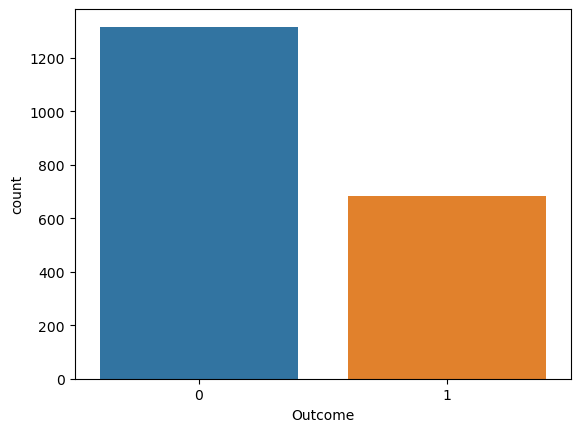

In [25]:
#outcome分布分析
a=df['Outcome'].value_counts()
print(a)
sns.countplot(x='Outcome',data=df)
plt.show()

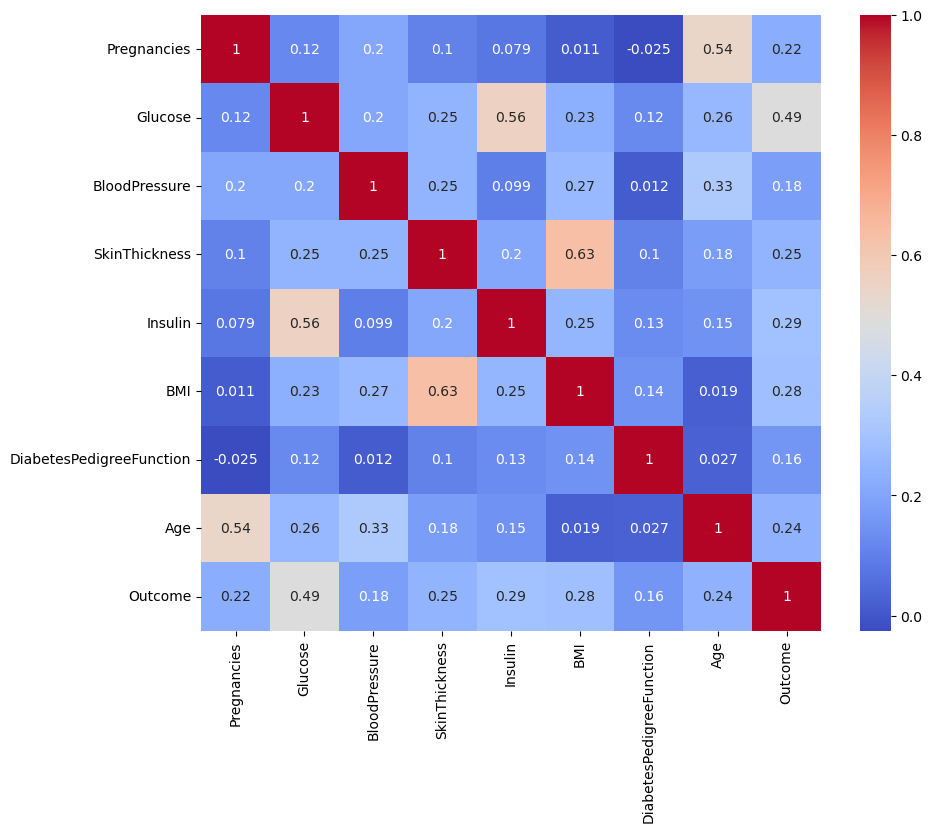

In [26]:
#绘制标签相关性热力图
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.show()

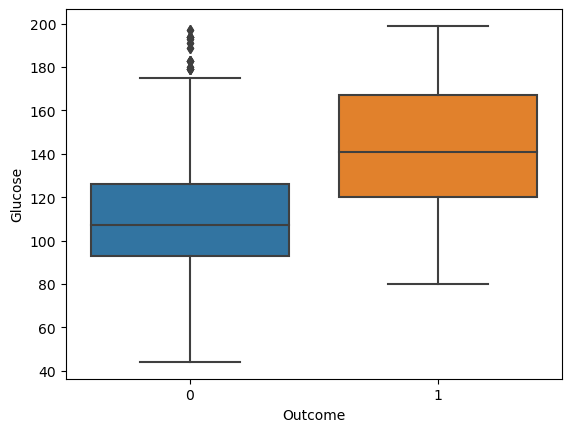

In [27]:
#glucose与outcome相关性
sns.boxplot(x='Outcome',y='Glucose',data=df)
plt.show()

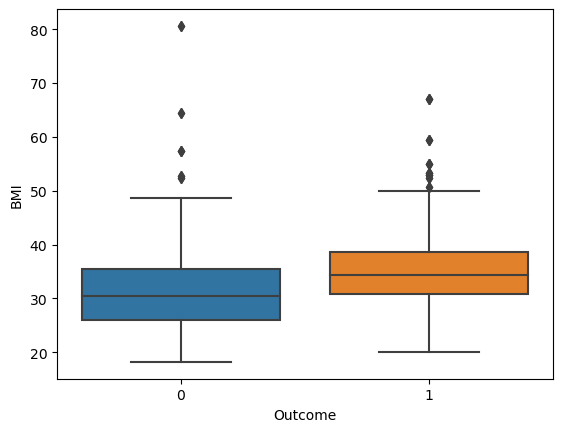

In [28]:
#bmi与outcome相关性
sns.boxplot(x='Outcome',y='BMI',data=df)
plt.show()

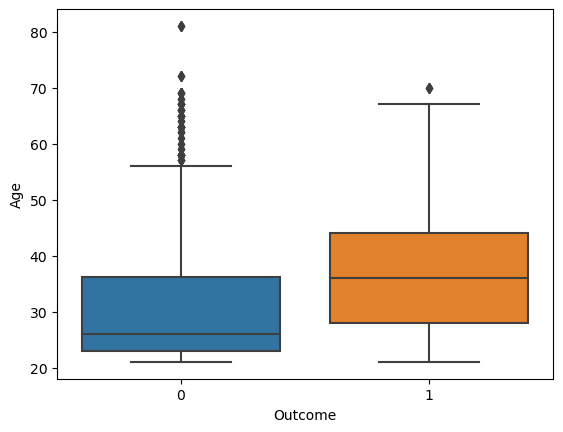

In [29]:
#age与outcome相关性
sns.boxplot(x='Outcome',y='Age',data=df)
plt.show()

<AxesSubplot:xlabel='Glucose', ylabel='Count'>

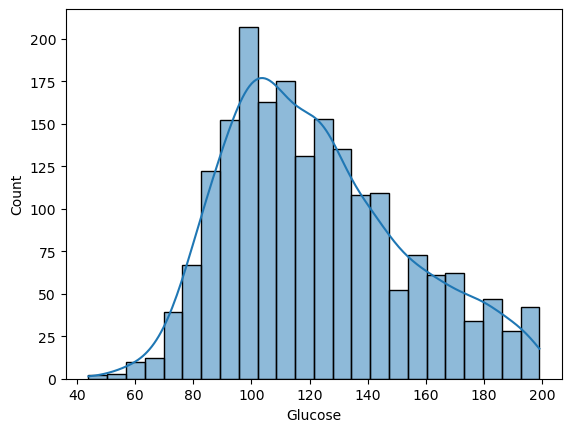

In [30]:
#glucose分布
sns.histplot(df['Glucose'],kde=True)

In [31]:
#定义xy
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [32]:
# 只针对 baseline，直接对 X 做中位数替换
imputer = SimpleImputer(strategy='median')
X_baseline = imputer.fit_transform(X)

# 核心修复 1：把 X_baseline 变回带列名的 DataFrame
# 假设 X 是你原始的、带列名的 DataFrame
X_baseline_df = pd.DataFrame(X_baseline, columns=X.columns)

# 核心修复 2：强制处理 y 的维度
df = X_baseline_df.copy()
df['Outcome'] = np.array(y).flatten() 

group0 = df[df['Outcome'] == 0]
group1 = df[df['Outcome'] == 1]

baseline_table = []

for col in X_baseline_df.columns:
    mean0 = group0[col].mean()
    mean1 = group1[col].mean()
    stat, p = ttest_ind(group0[col], group1[col])
    baseline_table.append([col, mean0, mean1, p])

baseline_df = pd.DataFrame(baseline_table, columns=['Feature', 'Non-Diabetes', 'Diabetes', 'p-value'])
print(baseline_df.sort_values('p-value'))


                    Feature  Non-Diabetes    Diabetes        p-value
1                   Glucose    111.208967  142.595029  5.175644e-120
5                       BMI     31.182979   35.462573   5.429376e-38
7                       Age     31.081307   36.956140   7.948734e-27
0               Pregnancies      3.168693    4.732456   2.968018e-24
3             SkinThickness     27.897416   31.833333   2.344999e-20
4                   Insulin    128.872340  162.818713   4.911916e-19
2             BloodPressure     70.885258   75.271930   4.332434e-15
6  DiabetesPedigreeFunction      0.434676    0.540681   2.738413e-12


In [33]:
# train / val / test = 70 / 15 / 15
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [34]:
# Logistic Regression
pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LogisticRegression(max_iter=1000))
])

# Random Forest
pipeline_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        max_depth=5,
        random_state=42
    ))
])
#svm
pipeline_svm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', SVC(probability=True))
])


#knn
pipeline_knn = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

models = {
    "Logistic Regression": pipeline_lr,
    "Random Forest": pipeline_rf,
    "SVM": pipeline_svm,
    "KNN": pipeline_knn
}

In [35]:
#画acc，prec，rec，f1图
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])
    
df_results = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1-score"
])
df_results = df_results.sort_values(by="F1-score", ascending=False)

print(df_results)

                 Model  Accuracy  Precision    Recall  F1-score
1        Random Forest  0.830000   0.831169  0.627451  0.715084
0  Logistic Regression  0.790000   0.746835  0.578431  0.651934
3                  KNN  0.746667   0.632653  0.607843  0.620000
2                  SVM  0.770000   0.770492  0.460784  0.576687


d:\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [36]:
#调模型
models = {
    "LR": (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=1000))
        ]),
        {'model__C': [0.1, 1, 10]}
    ),
    
    "RF": (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', RandomForestClassifier(random_state=42))
        ]),
        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [5, 10, None],
            'model__class_weight': [{0:1,1:2}, {0:1,1:3}]
        }
    ),
    
    "SVM": (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', SVC(probability=True))
        ]),
        {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['rbf']
        }
    ),
    
    "KNN": (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', KNeighborsClassifier())
        ]),
        {
            'model__n_neighbors': [3,5,7,9]
        }
    )
}

In [37]:
#训练最佳模型
results = []
roc_data = {}
pr_data = {}

for name, (model, param_grid) in models.items():
    
    print(f"\n===== {name} =====")
    
    grid = GridSearchCV(model, param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    
    y_prob_val = best_model.predict_proba(X_val)[:,1]
    
    best_f1 = 0
    best_t = 0.5
    
    for t in np.arange(0.4, 0.65, 0.02):
        y_pred_val = (y_prob_val > t).astype(int)
        f1 = f1_score(y_val, y_pred_val)
        
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    
    
    y_prob_test = best_model.predict_proba(X_test)[:,1]
    y_pred_test = (y_prob_test > best_t).astype(int)
    
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    
    roc_auc = roc_auc_score(y_test, y_prob_test)
    pr_auc = average_precision_score(y_test, y_prob_test)
    
    
    fpr, tpr, _ = roc_curve(y_test, y_prob_test)
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_test)
    
    roc_data[name] = (fpr, tpr, roc_auc)
    pr_data[name] = (recall_curve, precision_curve, pr_auc)
    
    results.append([
        name, precision, recall, f1, roc_auc, pr_auc, best_t
    ])


===== LR =====

===== RF =====

===== SVM =====

===== KNN =====


In [38]:
#保存最佳模型
best_models = {}

for name, (model, param_grid) in models.items():
    
    grid = GridSearchCV(model, param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    best_models[name] = best_model   

In [39]:
#最佳模型对比
results_df = pd.DataFrame(results, columns=[
    "Model", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC", "Threshold"
])

print("\n===== 模型对比 =====")
print(results_df)


===== 模型对比 =====
  Model  Precision    Recall        F1   ROC_AUC    PR_AUC  Threshold
0    LR   0.737374  0.715686  0.726368  0.876659  0.765359       0.40
1    RF   1.000000  0.892157  0.943005  0.997549  0.995558       0.64
2   SVM   0.819149  0.754902  0.785714  0.932214  0.888821       0.44
3   KNN   0.784314  0.784314  0.784314  0.938107  0.864307       0.40


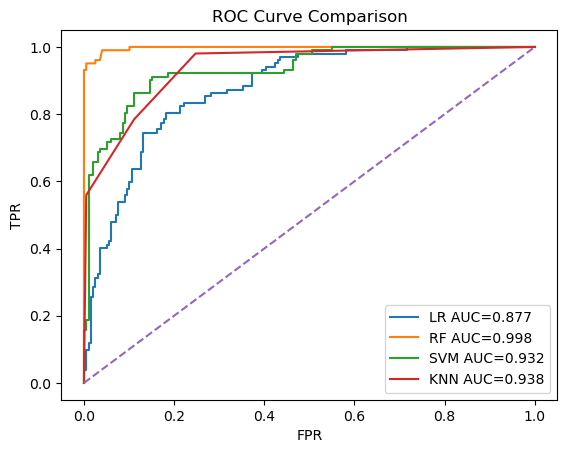

In [40]:
#roc曲线
plt.figure()

for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

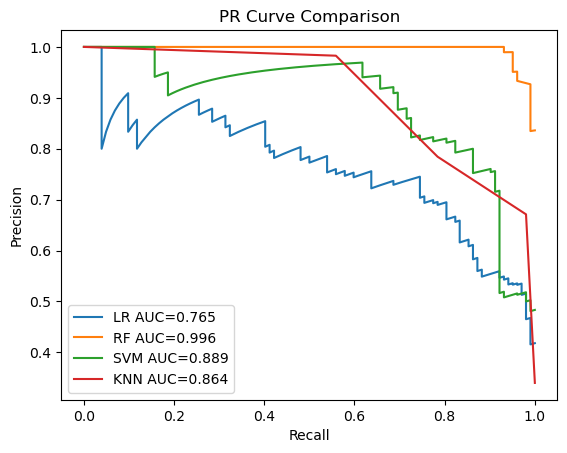

In [41]:
#pr曲线
plt.figure()

for name, (recall, precision, pr_auc) in pr_data.items():
    plt.plot(recall, precision, label=f"{name} AUC={pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR Curve Comparison")
plt.legend()

plt.show()

In [42]:
#模型对比
results = []

for name, (model, param_grid) in models.items():
    
    print(f"\n===== {name} =====")
    
    # 调参（只用train）
    grid = GridSearchCV(model, param_grid, cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    
    # 概率 
    y_prob_val = best_model.predict_proba(X_val)[:,1]
    y_prob_test = best_model.predict_proba(X_test)[:,1]
    
    
    # baseline（固定0.5）
    y_pred_base = (y_prob_test > 0.5).astype(int)
    
    base_precision = precision_score(y_test, y_pred_base)
    base_recall = recall_score(y_test, y_pred_base)
    base_f1 = f1_score(y_test, y_pred_base)
    
    
    #  优化threshold（限制范围）
    best_f1 = 0
    best_t = 0.5
    
    for t in np.arange(0.4, 0.65, 0.02):   
        y_pred_val = (y_prob_val > t).astype(int)
        f1 = f1_score(y_val, y_pred_val)
        
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    
    y_pred_opt = (y_prob_test > best_t).astype(int)
    
    opt_precision = precision_score(y_test, y_pred_opt)
    opt_recall = recall_score(y_test, y_pred_opt)
    opt_f1 = f1_score(y_test, y_pred_opt)
    
    # AUC（不受threshold影响）
    roc_auc = roc_auc_score(y_test, y_prob_test)
    pr_auc = average_precision_score(y_test, y_prob_test)
    
    results.append([
        name,
        base_precision, base_recall, base_f1,
        opt_precision, opt_recall, opt_f1,
        roc_auc, pr_auc,
        best_t
    ])


===== LR =====

===== RF =====

===== SVM =====

===== KNN =====


In [43]:
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Base_Precision", "Base_Recall", "Base_F1",
    "Opt_Precision", "Opt_Recall", "Opt_F1",
    "ROC_AUC", "PR_AUC",
    "Best_Threshold"
])

print("\n最终模型对比（报告版）")
print(results_df)


最终模型对比（报告版）
  Model  Base_Precision  Base_Recall   Base_F1  Opt_Precision  Opt_Recall  \
0    LR        0.756410     0.578431  0.655556       0.737374    0.715686   
1    RF        1.000000     0.931373  0.964467       1.000000    0.892157   
2   SVM        0.824176     0.735294  0.777202       0.819149    0.754902   
3   KNN        0.784314     0.784314  0.784314       0.784314    0.784314   

     Opt_F1   ROC_AUC    PR_AUC  Best_Threshold  
0  0.726368  0.876659  0.765359            0.40  
1  0.943005  0.997549  0.995558            0.64  
2  0.785714  0.932214  0.888821            0.44  
3  0.784314  0.938107  0.864307            0.40  


In [44]:
#五折交叉验证
from sklearn.model_selection import cross_val_score

rf_model = best_model   

scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)
print(f"RF Mean F1: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
print("RF CV F1 scores:", scores)

d:\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
d:\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to a

RF Mean F1: 0.7390 (+/- 0.0952)
RF CV F1 scores: [0.78756477 0.68539326 0.68783069 0.73631841 0.79787234]


d:\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
d:\anaconda3\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to a

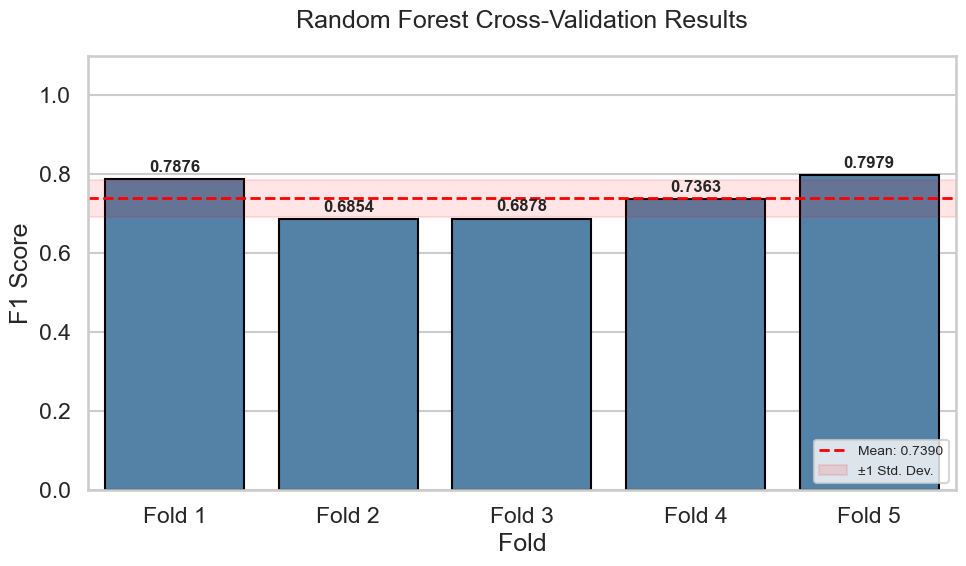

In [45]:
# 数据准备
scores_cv = scores 
mean_f1 = scores_cv.mean()
std_f1 = scores_cv.std()
folds = [f'Fold {i+1}' for i in range(len(scores_cv))]
df_scores = pd.DataFrame({'Fold': folds, 'F1 Score': scores_cv})

# 设置绘图风格
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(10, 6))

# 绘制柱状图
# color="skyblue" 或者使用 palette="viridis"
bar_plot = sns.barplot(x='Fold', y='F1 Score', data=df_scores, color="steelblue", edgecolor="black")

# 添加数值标签 (修正后的位置)
for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.4f', padding=3, fontsize=12, fontweight='bold')

# 添加均值线和标准差阴影
plt.axhline(mean_f1, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_f1:.4f}')
plt.axhspan(mean_f1 - std_f1, mean_f1 + std_f1, color='red', alpha=0.1, label='±1 Std. Dev.')

# 修饰图表
plt.title('Random Forest Cross-Validation Results', fontsize=18, pad=20)
plt.ylim(0, 1.1)
plt.ylabel('F1 Score')
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()


In [46]:
#提取rf重要特征
rf_model = best_models["RF"]
rf = rf_model.named_steps['model']
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp)

Glucose                     0.248013
BMI                         0.173223
Age                         0.138626
DiabetesPedigreeFunction    0.117509
Insulin                     0.101320
BloodPressure               0.080811
SkinThickness               0.072537
Pregnancies                 0.067960
dtype: float64


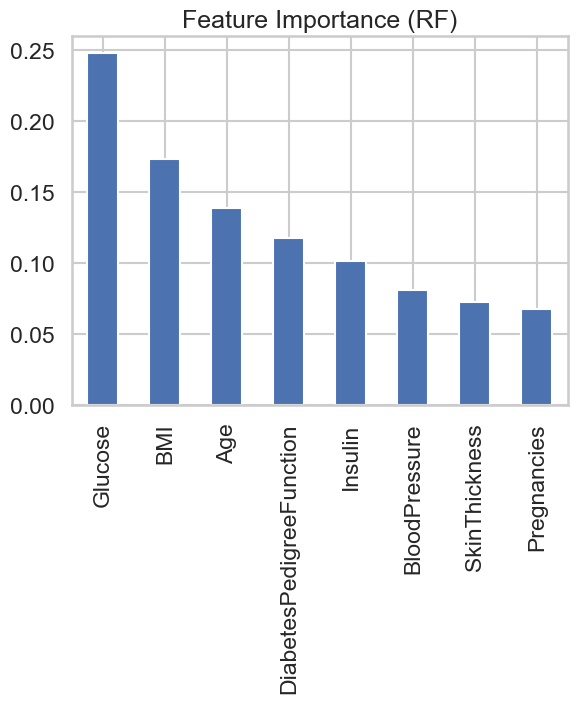

In [47]:
#可视化
plt.figure()
feat_imp.plot(kind='bar')
plt.title("Feature Importance (RF)")
plt.show()

<Figure size 1000x600 with 0 Axes>

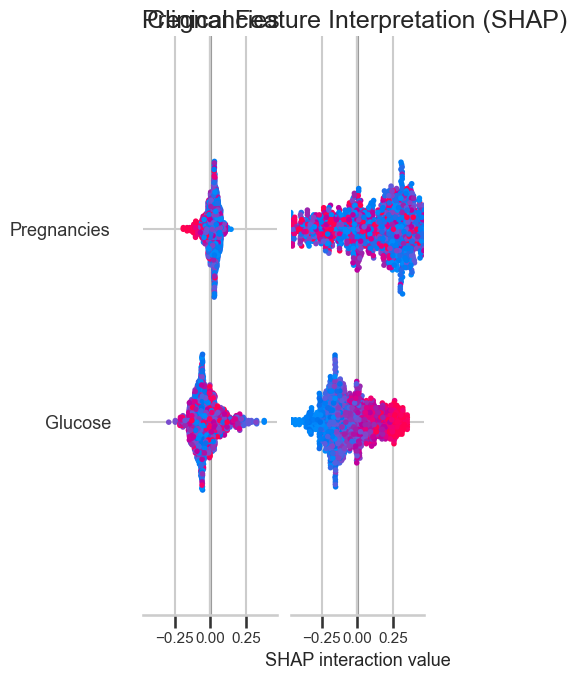

✅ 恭喜！SHAP 图已成功跑通。


In [49]:
import shap
# 提取rf最佳模型 
rf_pipeline = best_models['RF']

rf_model = rf_pipeline.named_steps['model']

# 用 Pipeline 里的预处理器处理原始数据
X_processed = rf_pipeline.named_steps['imputer'].transform(X_train)

#  还原为带列名的 DataFrame
X_display = pd.DataFrame(X_processed, columns=X.columns)

#  计算 SHAP 值
try:
    # 强制使用 TreeExplainer
    explainer = shap.TreeExplainer(rf_model)
    # 计算所有特征的 SHAP 值
    shap_values = explainer.shap_values(X_display)

    #  绘图逻辑
    plt.figure(figsize=(10, 6))
    
    # 通常展示 class1（即患糖尿病概率）的解释
    if isinstance(shap_values, list):
        shap_val_to_plot = shap_values[1]
    else:
        shap_val_to_plot = shap_values

    shap.summary_plot(shap_val_to_plot, X_display, show=False)
    
    # 导出图片
    plt.title("Clinical Feature Interpretation (SHAP)")
    plt.savefig("diabetes_shap_analysis.png", bbox_inches='tight', dpi=300)
    plt.show()
    print("✅ 恭喜！SHAP 图已成功跑通。")

except Exception as e:
    print(f"❌ 依然报错: {e}")
